In [2]:
# 🤖 Importación de librerías principales con alias estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection, metrics, preprocessing
import holidays

In [3]:
# Carga de los datos de ventas y competencia
ventas_path = '../data/raw/entrenamiento/ventas.csv'
competencia_path = '../data/raw/entrenamiento/competencia.csv'

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

print('Ventas shape:', ventas_df.shape)
print('Competencia shape:', competencia_df.shape)
ventas_df.head(), competencia_df.head()

Ventas shape: (3552, 10)
Competencia shape: (3552, 5)


(        fecha producto_id                            nombre categoria  \
 0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
 1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
 2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
 3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
 4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   
 
          subcategoria  precio_base  es_estrella  unidades_vendidas  \
 0  Zapatillas Running          115         True                  6   
 1  Zapatillas Running          135         True                 10   
 2  Zapatillas Running           85        False                  2   
 3  Zapatillas Running           75        False                  2   
 4        Ropa Running           35        False                  2   
 
    precio_venta  ingresos  
 0        118.36    710.16  
 1        136.82   1368.20  
 2         84.93    169.86  
 3        

In [4]:
# Validación de la calidad de datos de ventas
print('--- Tipos de variables ---')
print(ventas_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(ventas_df.isnull().sum())
print('\n--- Duplicados totales ---')
print(ventas_df.duplicated().sum())
print('\n--- Estadísticos descriptivos ---')
print(ventas_df.describe(include='all'))

# Informe final de calidad de datos
def informe_calidad(df):
    resumen = pd.DataFrame({
        'tipo': df.dtypes,
        'nulos': df.isnull().sum(),
        'nulos_%': df.isnull().mean()*100,
        'únicos': df.nunique(),
        'duplicados': df.duplicated().sum()
    })
    return resumen

print('\n--- Informe final de calidad de datos ---')
display(informe_calidad(ventas_df))

--- Tipos de variables ---
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- Valores nulos por columna ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- Duplicados totales ---
0

--- Estadísticos descriptivos ---
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148                

,tipo,nulos,nulos_%,únicos,duplicados
fecha,str,0,0.0,148,0
producto_id,str,0,0.0,24,0
nombre,str,0,0.0,24,0
categoria,str,0,0.0,4,0
subcategoria,str,0,0.0,16,0
precio_base,int64,0,0.0,21,0
es_estrella,bool,0,0.0,2,0
unidades_vendidas,int64,0,0.0,52,0
precio_venta,float64,0,0.0,2537,0
ingresos,float64,0,0.0,3033,0


In [5]:
# Validación de la calidad de datos de competencia
print('--- Tipos de variables ---')
print(competencia_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(competencia_df.isnull().sum())
print('\n--- Duplicados totales ---')
print(competencia_df.duplicated().sum())
print('\n--- Estadísticos descriptivos ---')
print(competencia_df.describe(include='all'))

print('\n--- Informe final de calidad de datos ---')
display(informe_calidad(competencia_df))

--- Tipos de variables ---
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- Valores nulos por columna ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- Duplicados totales ---
0

--- Estadísticos descriptivos ---
             fecha producto_id       Amazon    Decathlon  Deporvillage
count         3552        3552  3552.000000  3552.000000   3552.000000
unique         148          24          NaN          NaN           NaN
top     2021-10-25    PROD_001          NaN          NaN           NaN
freq            24         148          NaN          NaN           NaN
mean           NaN         NaN   118.623407   111.412182    118.894628
std            NaN         NaN   156.095628   148.508132    160.216448
min            NaN         NaN    16.850000    15.450000     16.770000
25%            NaN         NaN    47.117500    43.285000     47.3100

,tipo,nulos,nulos_%,únicos,duplicados
fecha,str,0,0.0,148,0
producto_id,str,0,0.0,24,0
Amazon,float64,0,0.0,3125,0
Decathlon,float64,0,0.0,3001,0
Deporvillage,float64,0,0.0,3105,0


In [6]:
# Conversión de la columna 'fecha' a datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

print('Tipo de fecha en ventas_df:', ventas_df['fecha'].dtype)
print('Tipo de fecha en competencia_df:', competencia_df['fecha'].dtype)

Tipo de fecha en ventas_df: datetime64[us]
Tipo de fecha en competencia_df: datetime64[us]


In [7]:
ventas_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB


In [8]:
competencia_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB


In [9]:
# Integración de ventas_df y competencia_df en un único dataframe df

df = pd.merge(
    ventas_df,
    competencia_df,
    on=['fecha', 'producto_id'],
    how='left',
    suffixes=('', '_competencia')
)

print('Shape del dataframe integrado:', df.shape)
df.head()

Shape del dataframe integrado: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio de datos (EDA)
A continuación se presentan diferentes análisis y visualizaciones para entender el comportamiento de las ventas y la competencia.

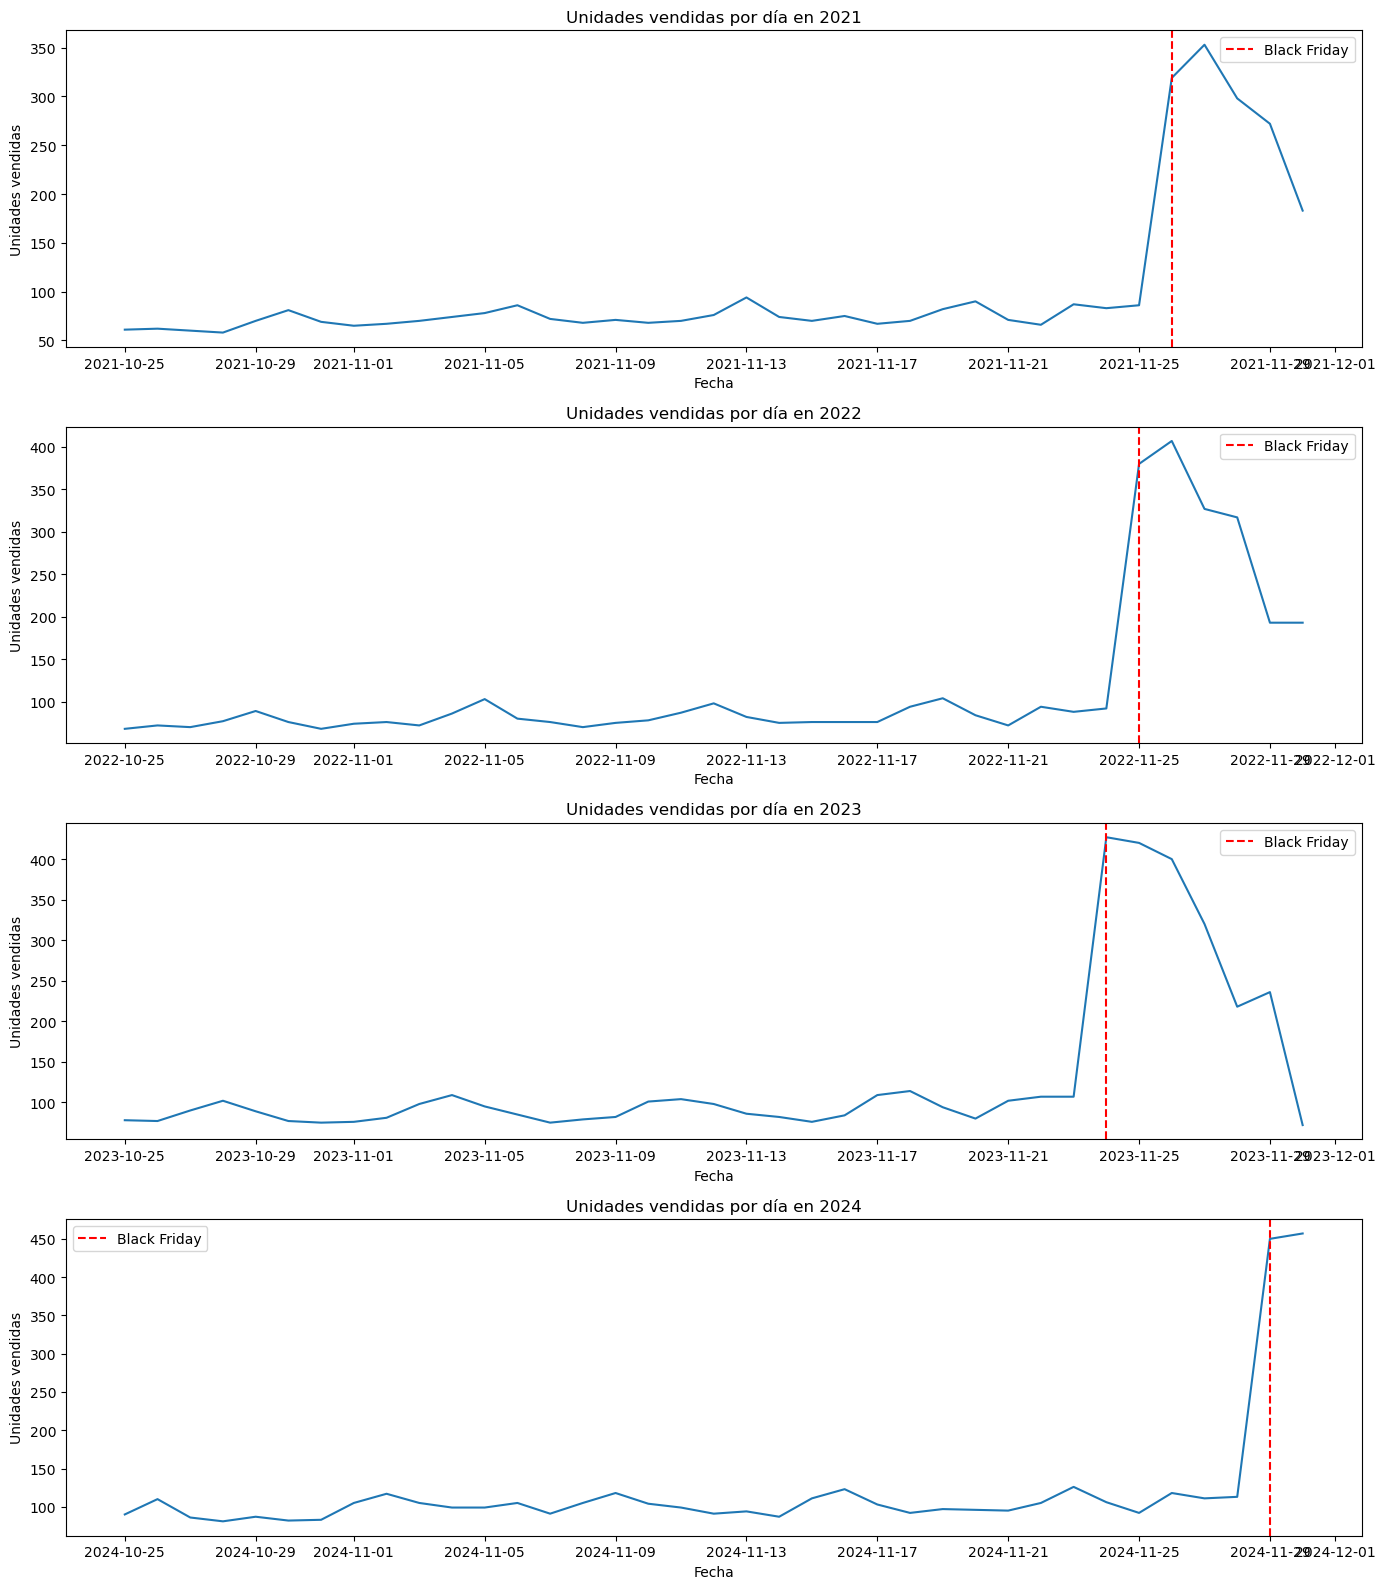

In [10]:
# Gráfico de líneas por año con suma de unidades vendidas y marcando Black Fridays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Aseguramos que la columna fecha es datetime
if not np.issubdtype(df['fecha'].dtype, np.datetime64):
    df['fecha'] = pd.to_datetime(df['fecha'])

# Definir fechas de Black Friday (último viernes de noviembre de cada año)
def black_fridays(years):
    bfs = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        bfs.append(fridays[-1])
    return bfs

years = df['fecha'].dt.year.unique()
bf_dates = black_fridays(years)

fig, axes = plt.subplots(len(years), 1, figsize=(14, 4*len(years)), sharex=False)
if len(years) == 1:
    axes = [axes]
for i, year in enumerate(sorted(years)):
    data = df[df['fecha'].dt.year == year]
    daily = data.groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(ax=axes[i], x=daily.index, y=daily.values)
    axes[i].set_title(f'Unidades vendidas por día en {year}')
    axes[i].set_ylabel('Unidades vendidas')
    axes[i].set_xlabel('Fecha')
    # Marcar Black Friday
    bf = [d for d in bf_dates if d.year == year]
    for bfd in bf:
        axes[i].axvline(bfd, color='red', linestyle='--', label='Black Friday')
    axes[i].legend()
plt.tight_layout()
plt.show()

C:\Users\Alberto\AppData\Local\Temp\ipykernel_10888\1675541197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'],


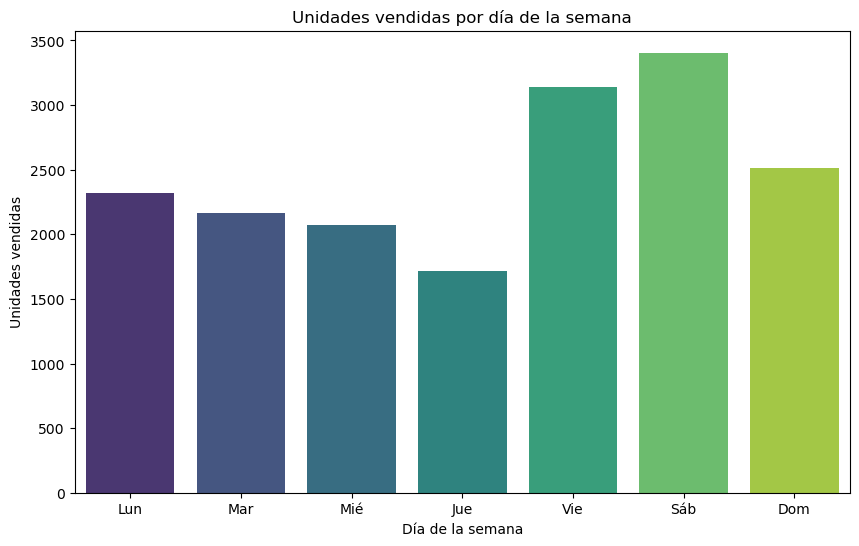

In [11]:
# Gráfico de suma de unidades vendidas por día de la semana
# 0=Lunes, 6=Domingo

df['dia_semana'] = df['fecha'].dt.dayofweek
plt.figure(figsize=(10,6))
sns.barplot(x=['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'],
            y=df.groupby('dia_semana')['unidades_vendidas'].sum().values,
            palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.show()

C:\Users\Alberto\AppData\Local\Temp\ipykernel_10888\12689646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index,


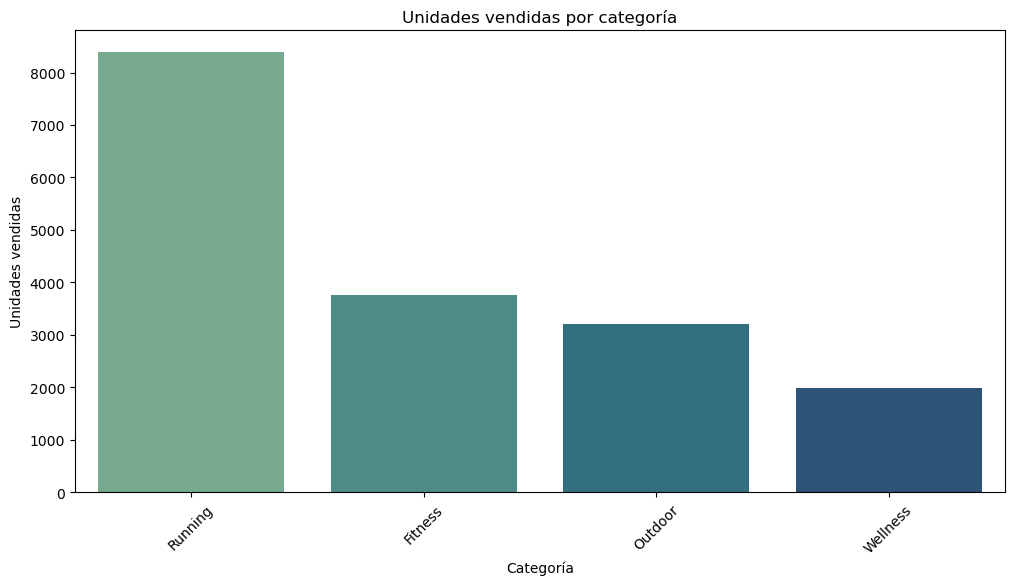

In [12]:
# Gráfico de suma de unidades vendidas por categoría
plt.figure(figsize=(12,6))
sns.barplot(x=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).index,
            y=df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False).values,
            palette='crest')
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.show()

C:\Users\Alberto\AppData\Local\Temp\ipykernel_10888\1871223782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index,


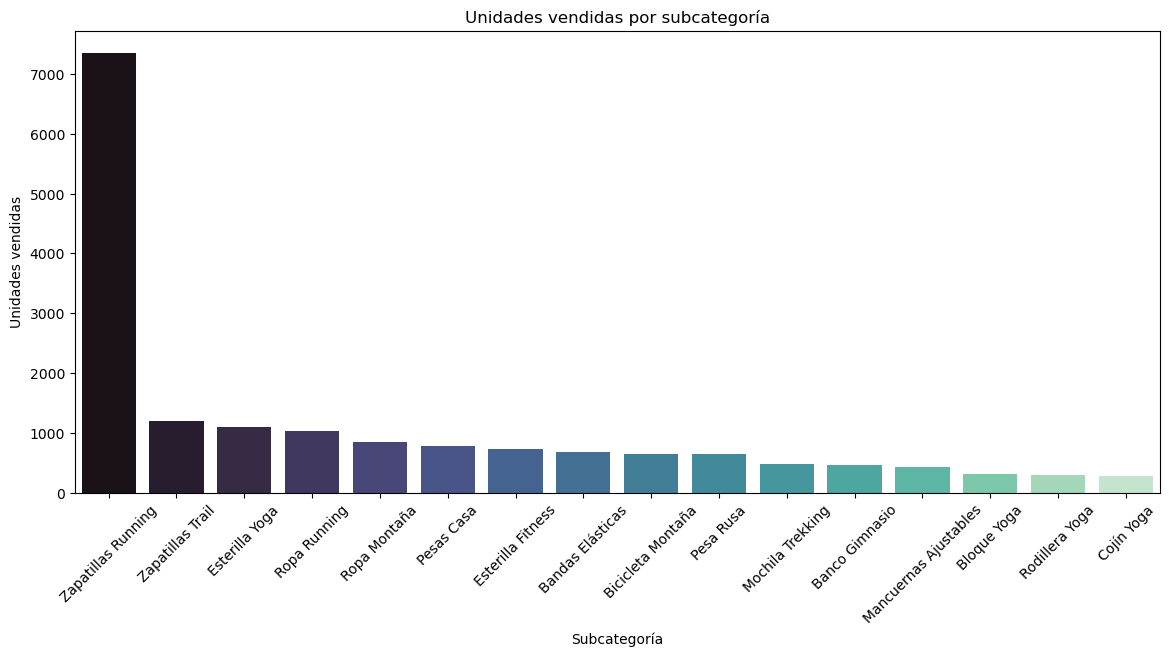

In [13]:
# Gráfico de suma de unidades vendidas por subcategoría
plt.figure(figsize=(14,6))
sns.barplot(x=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).index,
            y=df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False).values,
            palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.show()

C:\Users\Alberto\AppData\Local\Temp\ipykernel_10888\212582780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.index, y=top_productos.values, palette='flare')


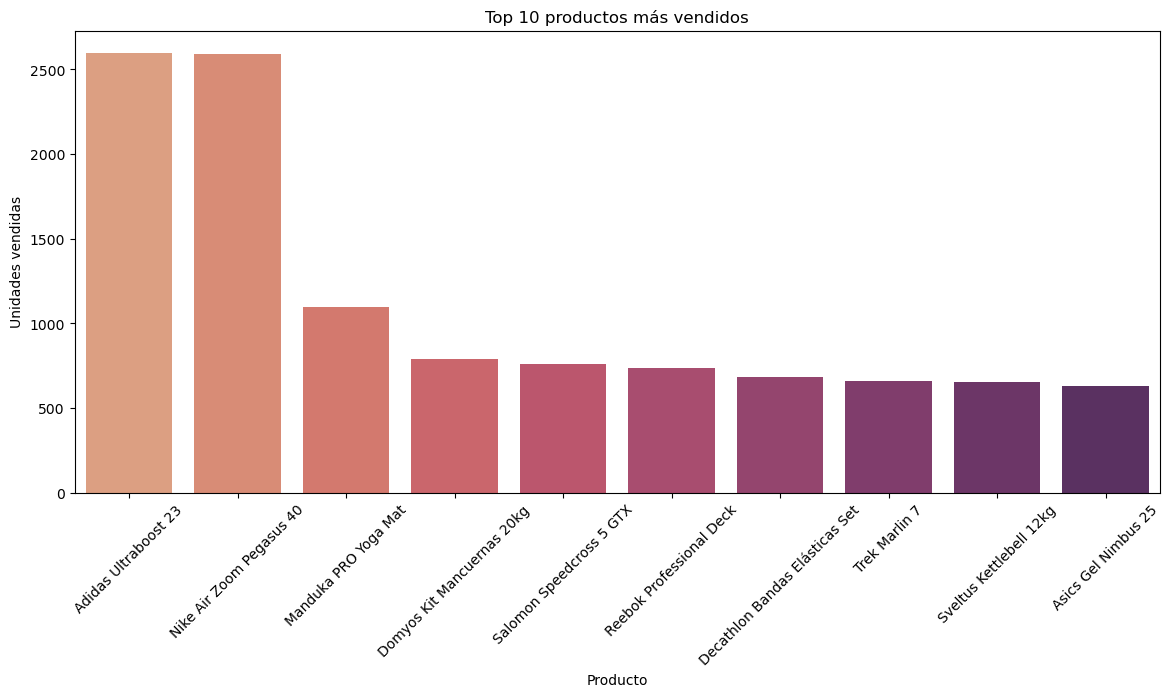

In [14]:
# Gráfico de los top 10 productos más vendidos
plt.figure(figsize=(14,6))
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_productos.index, y=top_productos.values, palette='flare')
plt.title('Top 10 productos más vendidos')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.show()

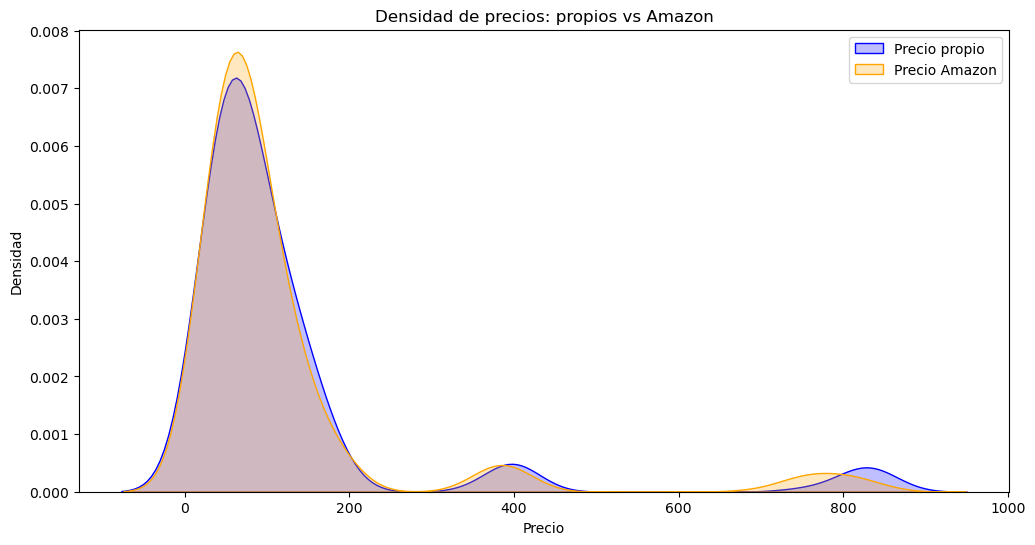

In [15]:
plt.figure(figsize=(12,6))
sns.kdeplot(ventas_df['precio_venta'], label='Precio propio', fill=True, color='blue')

if 'Amazon' in competencia_df.columns:
    ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
    competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])
    merged = pd.merge(
        ventas_df[['fecha', 'producto_id', 'precio_venta']],
        competencia_df[['fecha', 'producto_id', 'Amazon']],
        on=['fecha', 'producto_id'],
        how='left'
    )
    merged['Amazon'] = pd.to_numeric(merged['Amazon'], errors='coerce')
    sns.kdeplot(merged['Amazon'].dropna(), label='Precio Amazon', fill=True, color='orange')

plt.title('Densidad de precios: propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.show()

### Creación de variables temporales y de calendario
A continuación se crean variables temporales y de calendario útiles para el análisis y modelado, utilizando la librería `holidays` para identificar festivos en España.

In [16]:
# Variables temporales y de calendario
import holidays

df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes

df['es_fin_de_semana'] = df['dia_semana'].isin([5,6])

# Festivos nacionales en España
es_holidays = holidays.country_holidays('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(es_holidays)

# Black Friday: último viernes de noviembre
def es_black_friday(fecha):
    if fecha.month != 11:
        return False
    ultimo_viernes = max([d for d in pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30') if d.weekday() == 4])
    return fecha == ultimo_viernes

df['es_black_friday'] = df['fecha'].apply(es_black_friday)

# Cyber Monday: primer lunes después de Black Friday
def es_cyber_monday(fecha):
    if fecha.month != 11 and fecha.month != 12:
        return False
    # Encuentra el Black Friday de ese año
    ultimo_viernes = max([d for d in pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30') if d.weekday() == 4])
    cyber_monday = ultimo_viernes + pd.Timedelta(days=3)
    return fecha == cyber_monday

df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

# Variables adicionales
# Semana del año
df['semana_año'] = df['fecha'].dt.isocalendar().week
# Día del año
df['dia_año'] = df['fecha'].dt.dayofyear
# Primer/último día de mes
df['es_primer_dia_mes'] = df['dia_mes'] == 1
df['es_ultimo_dia_mes'] = df['fecha'] == df['fecha'] + pd.offsets.MonthEnd(0)
# Trimestre
df['trimestre'] = df['fecha'].dt.quarter
# Es festivo o fin de semana
df['es_festivo_o_finde'] = df['es_festivo'] | df['es_fin_de_semana']

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_fin_de_semana,es_festivo,es_black_friday,es_cyber_monday,semana_año,dia_año,es_primer_dia_mes,es_ultimo_dia_mes,trimestre,es_festivo_o_finde
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,43,298,False,False,4,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,False,False,False,43,298,False,False,4,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,False,False,False,43,298,False,False,4,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,False,False,43,298,False,False,4,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,False,False,43,298,False,False,4,False


In [17]:
df.shape

(3552, 27)

### Creación de variables de lag y medias móviles
Se crean los lags de unidades vendidas (1 a 7 días) y la media móvil de 7 días, calculados por producto y año para evitar mezclas entre años.

In [18]:
# Lags y media móvil de unidades vendidas (por producto y año)
for lag in range(1, 8):
    df[f'unidades_vendidas_lag{lag}'] = (
        df.sort_values(['producto_id', 'año', 'fecha'])
          .groupby(['producto_id', 'año'])['unidades_vendidas']
          .shift(lag)
    )

# Media móvil de 7 días (por producto y año)
df['unidades_vendidas_mm7'] = (
    df.sort_values(['producto_id', 'año', 'fecha'])
      .groupby(['producto_id', 'año'])['unidades_vendidas']
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Eliminar registros con nulos en cualquiera de las nuevas variables
df = df.dropna(subset=[f'unidades_vendidas_lag{lag}' for lag in range(1,8)] + ['unidades_vendidas_mm7'])
df = df.reset_index(drop=True)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,trimestre,es_festivo_o_finde,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,4,False,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000
1,2021-11-01,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.00,1360.00,...,4,False,10.0,12.0,9.0,8.0,8.0,10.0,10.0,9.571429
2,2021-11-01,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,85.14,170.28,...,4,False,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.571429
3,2021-11-01,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,76.74,153.48,...,4,False,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.285714
4,2021-11-01,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,34.89,69.78,...,4,False,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.000000


In [19]:
df.groupby('año').size()

año
2021    720
2022    720
2023    720
2024    720
dtype: int64

### Creación de la variable de descuento porcentual
Se añade la variable `descuento_porcentaje` como el porcentaje de descuento aplicado sobre el precio base.

In [20]:
# Variable descuento porcentaje
# (precio_venta - precio_base) / precio_base * 100
df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100
df[['fecha', 'producto_id', 'precio_venta', 'precio_base', 'descuento_porcentaje']].head()

,fecha,producto_id,precio_venta,precio_base,descuento_porcentaje
0,2021-11-01,PROD_001,115.07,115,0.060870
1,2021-11-01,PROD_002,136.00,135,0.740741
2,2021-11-01,PROD_003,85.14,85,0.164706
3,2021-11-01,PROD_004,76.74,75,2.320000
4,2021-11-01,PROD_005,34.89,35,-0.314286


### Creación de variables de precio de competencia y ratio de precio
Se añade la variable `precio_competencia` como el promedio de los precios de Amazon, Decathlon y Deporvillage, y la variable `ratio_precio` como el cociente entre nuestro precio y el precio promedio de la competencia. Se eliminan las columnas originales de los competidores.

In [21]:
# Variable precio_competencia y ratio_precio
competidores = ['Amazon', 'Decathlon', 'Deporvillage']
# Convertir a numérico por si acaso
for col in competidores:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['precio_competencia'] = df[competidores].mean(axis=1)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
# Eliminar columnas originales de competidores
df = df.drop(columns=competidores)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,descuento_porcentaje,precio_competencia,ratio_precio
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,12.0,12.0,7.0,8.0,8.0,6.0,9.000000,0.060870,95.353333,1.206775
1,2021-11-01,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.00,1360.00,...,12.0,9.0,8.0,8.0,10.0,10.0,9.571429,0.740741,113.393333,1.199365
2,2021-11-01,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,85.14,170.28,...,3.0,3.0,2.0,3.0,2.0,2.0,2.571429,0.164706,83.276667,1.022375
3,2021-11-01,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,76.74,153.48,...,3.0,2.0,2.0,2.0,2.0,2.0,2.285714,2.320000,71.843333,1.068158
4,2021-11-01,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,34.89,69.78,...,2.0,2.0,2.0,2.0,2.0,2.0,2.000000,-0.314286,33.490000,1.041804


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   fecha                   2880 non-null   datetime64[us]
 1   producto_id             2880 non-null   str           
 2   nombre                  2880 non-null   str           
 3   categoria               2880 non-null   str           
 4   subcategoria            2880 non-null   str           
 5   precio_base             2880 non-null   int64         
 6   es_estrella             2880 non-null   bool          
 7   unidades_vendidas       2880 non-null   int64         
 8   precio_venta            2880 non-null   float64       
 9   ingresos                2880 non-null   float64       
 10  dia_semana              2880 non-null   int32         
 11  año                     2880 non-null   int32         
 12  mes                     2880 non-null   int32         
 13 

### One Hot Encoding de variables categóricas
Se crean copias de las variables `nombre`, `categoria` y `subcategoria` con el sufijo `_h` y se aplica one hot encoding sobre ellas.

In [23]:
# Copia de variables categóricas con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding
df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-01,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.00,1360.00,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-01,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,85.14,170.28,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-01,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,76.74,153.48,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-01,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,34.89,69.78,...,False,False,False,False,False,False,False,True,False,False


### Guardado del dataframe procesado
Se guarda el dataframe final `df` en la carpeta `data/processed`.

In [24]:
# Guardar el dataframe procesado
df.to_csv('../data/processed/df.csv', index=False)
print('Dataframe guardado en data/processed/df.csv')

Dataframe guardado en data/processed/df.csv


In [25]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'dia_semana', 'año', 'mes', 'dia_mes', 'es_fin_de_semana',
       'es_festivo', 'es_black_friday', 'es_cyber_monday', 'semana_año',
       'dia_año', 'es_primer_dia_mes', 'es_ultimo_dia_mes', 'trimestre',
       'es_festivo_o_finde', 'unidades_vendidas_lag1',
       'unidades_vendidas_lag2', 'unidades_vendidas_lag3',
       'unidades_vendidas_lag4', 'unidades_vendidas_lag5',
       'unidades_vendidas_lag6', 'unidades_vendidas_lag7',
       'unidades_vendidas_mm7', 'descuento_porcentaje', 'precio_competencia',
       'ratio_precio', 'nombre_h_Adidas Own The Run Jacket',
       'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25',
       'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas

### División del dataframe en train y validation
Se divide el dataframe en `train_df` (años 2021 a 2023) y `validation_df` (año 2024) y se muestra el número de registros de cada conjunto.

In [26]:
# División en train y validation
years_train = [2021, 2022, 2023]
year_val = 2024
train_df = df[df['año'].isin(years_train)].copy()
validation_df = df[df['año'] == year_val].copy()
print(f'Registros en train_df (2021-2023): {len(train_df)}')
print(f'Registros en validation_df (2024): {len(validation_df)}')

Registros en train_df (2021-2023): 2160
Registros en validation_df (2024): 720


### Entrenamiento de HistGradientBoostingRegressor y comparación con baseline
Se entrena un modelo HistGradientBoostingRegressor con parámetros conservadores y se compara con un baseline naïf (media histórica).

In [27]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Selección de variables predictoras (excluyendo fecha, ingresos y tipo object/string)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [col for col in train_df.columns if col not in excluir and train_df[col].dtype != 'O' and train_df[col].dtype != 'str']

X_train = train_df[X_cols]
y_train = train_df['unidades_vendidas']
X_val = validation_df[X_cols]
y_val = validation_df['unidades_vendidas']

# Modelo conservador
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naïf: predice la media de train
y_pred_naif = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naif = mean_absolute_error(y_val, y_pred_naif)
mse_naif = mean_squared_error(y_val, y_pred_naif)
rmse_naif = np.sqrt(mse_naif)
r2_naif = r2_score(y_val, y_pred_naif)

print('--- HistGradientBoostingRegressor ---')
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.3f}')
print('\n--- Baseline Naïf (media) ---')
print(f'MAE:  {mae_naif:.2f}')
print(f'RMSE: {rmse_naif:.2f}')
print(f'R2:   {r2_naif:.3f}')

--- HistGradientBoostingRegressor ---
MAE:  0.78
RMSE: 1.75
R2:   0.932

--- Baseline Naïf (media) ---
MAE:  3.67
RMSE: 6.69
R2:   -0.000


### Predicción y visualización para productos estrella en noviembre 2024
Se generan predicciones para los 7 productos estrella en noviembre de 2024 y se grafican las predicciones frente a la realidad para cada producto.

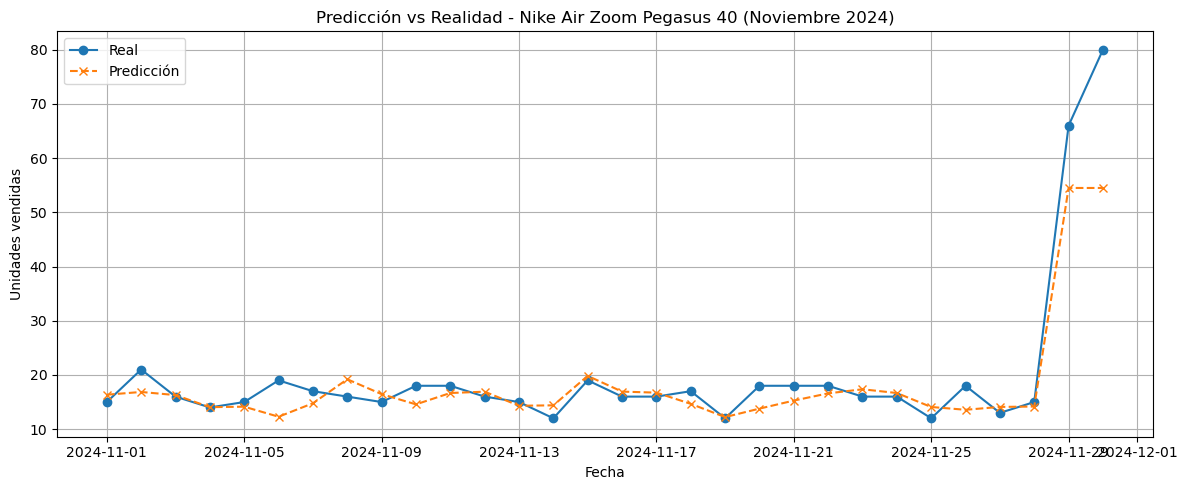

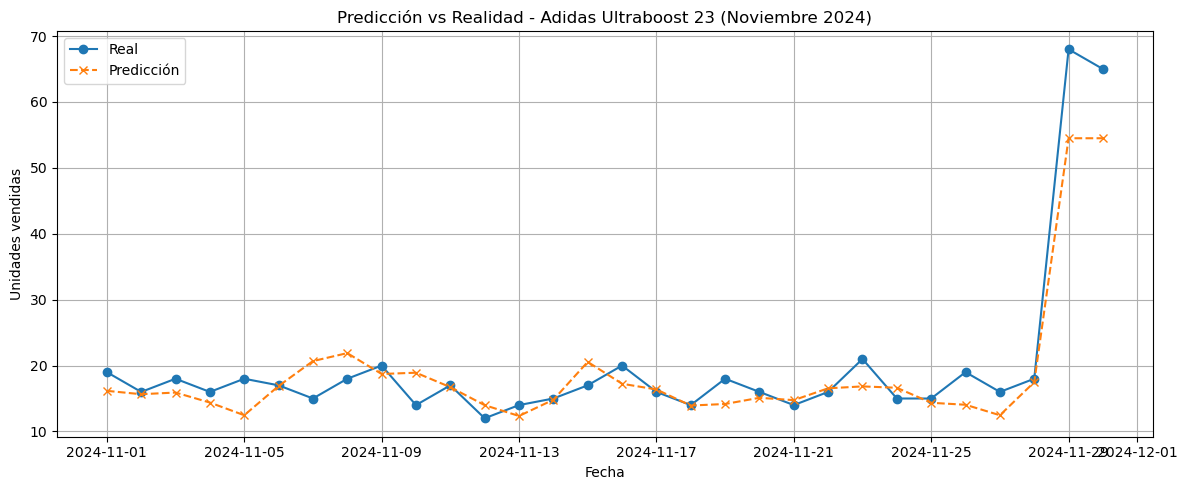

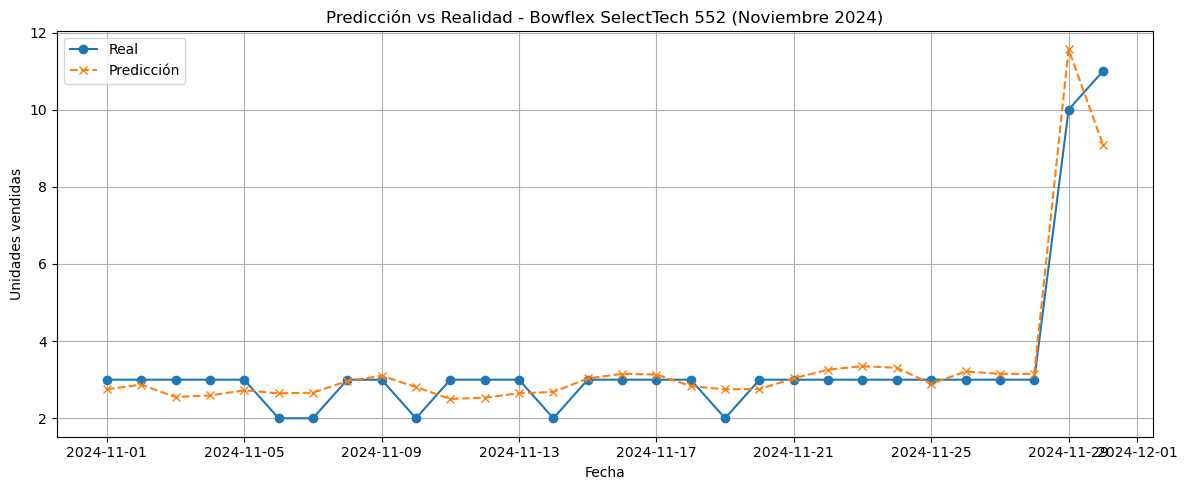

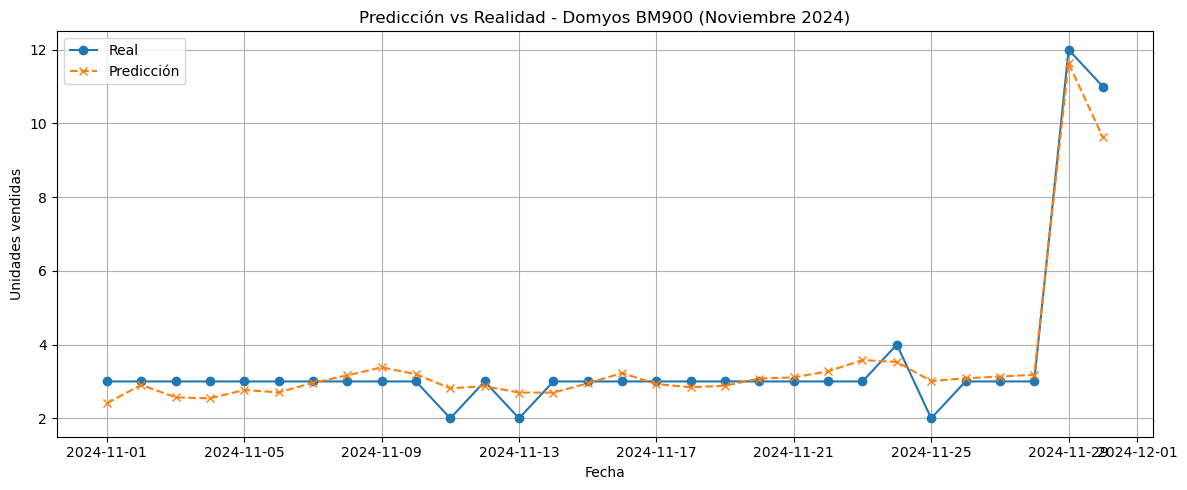

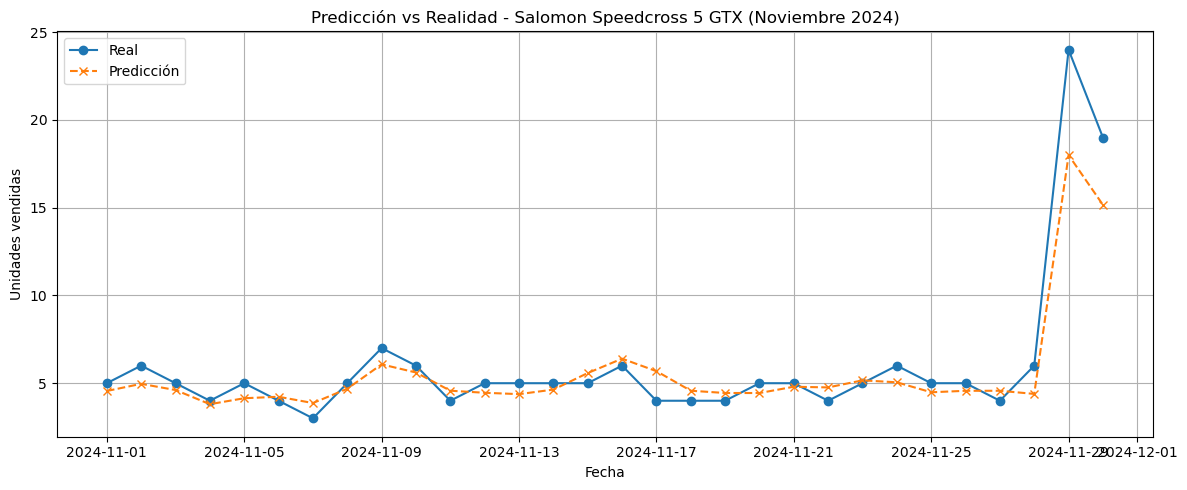

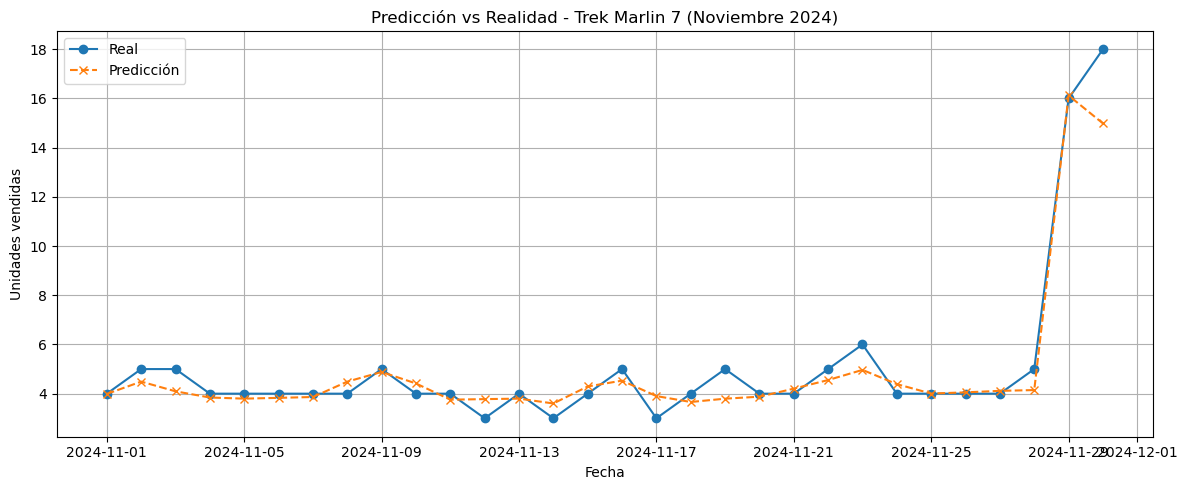

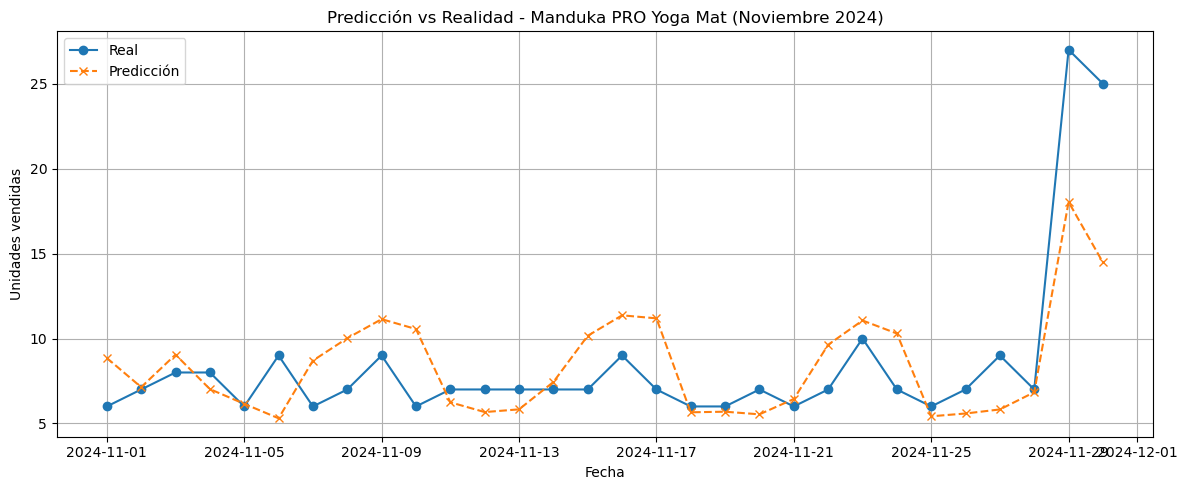

In [28]:
# Predicción y visualización para productos estrella en noviembre 2024

# Selección de productos estrella
productos_estrella = df[df['es_estrella'] == 1]['nombre'].unique()[:7]

# Filtrar noviembre 2024 y productos estrella
nov_2024 = (validation_df['fecha'].dt.year == 2024) & (validation_df['fecha'].dt.month == 11)
df_nov = validation_df[nov_2024 & validation_df['nombre'].isin(productos_estrella)].copy()

# Predecir para cada producto estrella
for producto in productos_estrella:
    datos_prod = df_nov[df_nov['nombre'] == producto].copy()
    if datos_prod.empty:
        continue
    X_prod = datos_prod[X_cols]
    y_real = datos_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    fechas = datos_prod['fecha']

    plt.figure(figsize=(12,5))
    plt.plot(fechas, y_real, marker='o', label='Real')
    plt.plot(fechas, y_pred, marker='x', linestyle='--', label='Predicción')
    plt.title(f'Predicción vs Realidad - {producto} (Noviembre 2024)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Reentrenamiento del modelo final con todos los datos históricos
Entrenamos un nuevo modelo HistGradientBoostingRegressor usando todo el dataframe `df` desde 2021 hasta 2024 como conjunto de entrenamiento, con los mismos parámetros y variables seleccionadas anteriormente.

In [29]:
# Reentrenamiento del modelo final con todo el histórico (2021-2024)
from sklearn.ensemble import HistGradientBoostingRegressor

# Selección de variables predictoras (igual que antes)
excluir = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols_final = [col for col in df.columns if col not in excluir and df[col].dtype != 'O' and df[col].dtype != 'str']

X_full = df[X_cols_final]
y_full = df['unidades_vendidas']

# Entrenamiento del modelo final
modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
modelo_final.fit(X_full, y_full)

print('Modelo final entrenado con todo el histórico (2021-2024)')

Modelo final entrenado con todo el histórico (2021-2024)


### Importancia de variables y guardado del modelo final
Calculamos la importancia de variables usando permutation importance sobre el modelo final y representamos los resultados en un gráfico de barras horizontales. Finalmente, guardamos el modelo entrenado en la carpeta `models`.

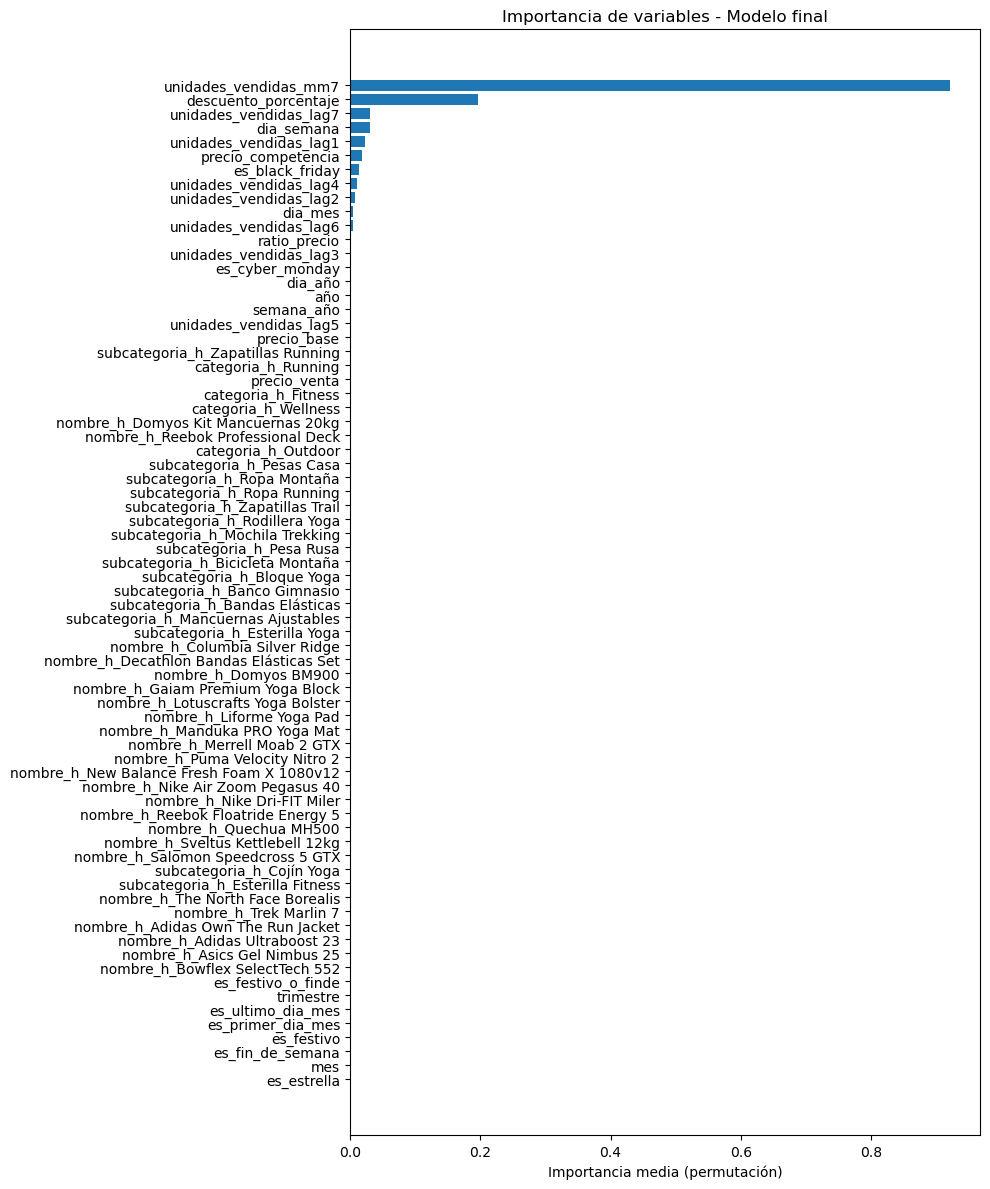

Modelo final guardado en models/modelo_final.joblib


In [30]:
# Importancia de variables con permutation importance y guardado del modelo final
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Calculamos la importancia de variables (permutation importance)
result = permutation_importance(
    modelo_final, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1
)

importancias = result.importances_mean
indices = np.argsort(importancias)[::-1]

plt.figure(figsize=(10, 12))
plt.barh(range(len(indices)), importancias[indices], align='center')
plt.yticks(range(len(indices)), [X_cols_final[i] for i in indices])
plt.xlabel('Importancia media (permutación)')
plt.title('Importancia de variables - Modelo final')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
joblib.dump(modelo_final, '../models/modelo_final.joblib')
print('Modelo final guardado en models/modelo_final.joblib')